Dataset Shape: (1000, 8)

First 5 rows:
    Square_Footage  Num_Bedrooms  Num_Bathrooms  Year_Built  Lot_Size  \
0            1360             2              1        1981  0.599637   
1            4272             3              3        2016  4.753014   
2            3592             1              2        2016  3.634823   
3             966             1              2        1977  2.730667   
4            4926             2              1        1993  4.699073   

   Garage_Size  Neighborhood_Quality   House_Price  
0            0                     5  2.623829e+05  
1            1                     6  9.852609e+05  
2            0                     9  7.779774e+05  
3            1                     8  2.296989e+05  
4            0                     8  1.041741e+06  

Summary Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                ---------

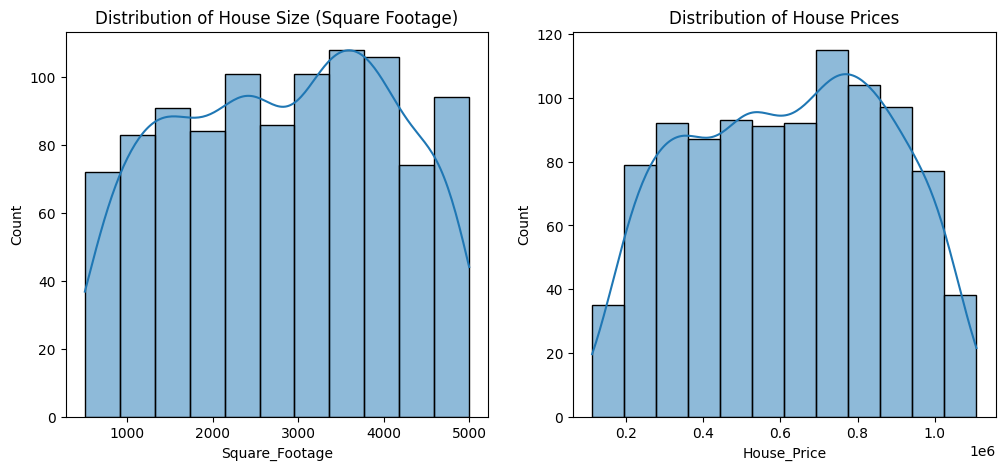

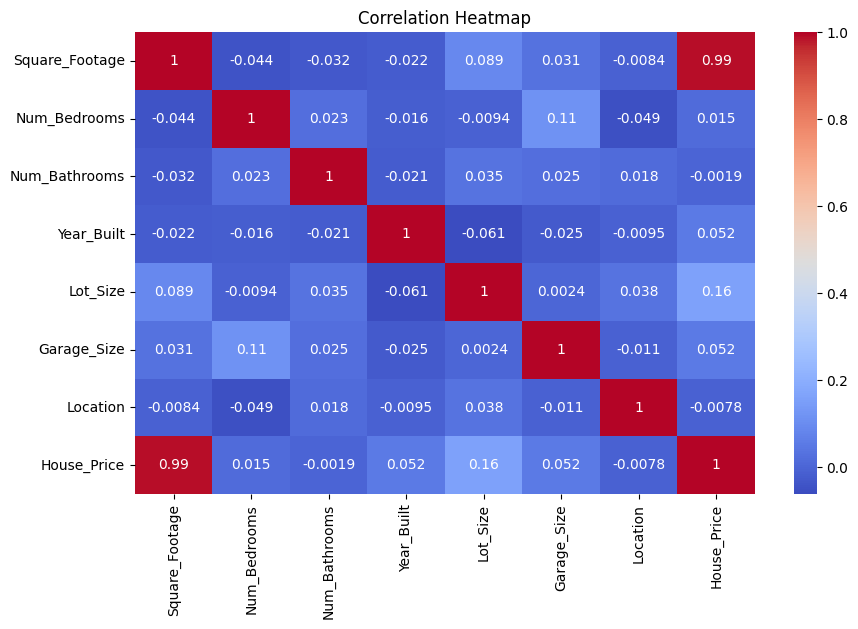


Model Performance:
Root Mean Squared Error (RMSE): 29459.42688738146
R² Score: 0.9865362516221438


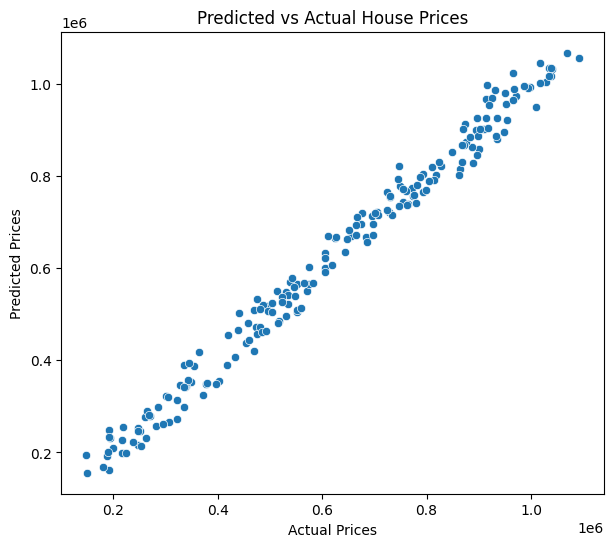


Feature Importance:
              Feature    Coefficient
0     Square_Footage  251551.116647
1       Num_Bedrooms   14733.811475
3     Location_Urban    2678.749371
2  Location_Suburban    1321.494493


In [2]:

# Task 4: Regression Analysis - Predict House Prices
# Internship Project

# ===============================
# 1. Import Libraries
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

# ===============================
# 2. Load and Explore Dataset
# ===============================
file_path = "house_price_regression_dataset.csv"   # update path if needed
df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nSummary Info:\n")
print(df.info())
print("\nMissing values:\n", df.isnull().sum())

# ===============================
# 3. Basic EDA
# ===============================

# Rename Neighborhood_Quality → Location (categorical conversion later)
df = df.rename(columns={"Neighborhood_Quality": "Location"})

# Distribution plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df["Square_Footage"], kde=True)
plt.title("Distribution of House Size (Square Footage)")

plt.subplot(1, 2, 2)
sns.histplot(df["House_Price"], kde=True)
plt.title("Distribution of House Prices")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ===============================
# 4. Data Preprocessing
# ===============================

# Convert numeric Location → categorical bins (Rural, Suburban, Urban)
df["Location"] = pd.cut(
    df["Location"], bins=[0, 3, 6, 10],
    labels=["Rural", "Suburban", "Urban"]
)

# Select features & target
X = df[["Square_Footage", "Num_Bedrooms", "Location"]]
y = df["House_Price"]

# Column transformer: scale numeric + encode categorical
numeric_features = ["Square_Footage", "Num_Bedrooms"]
categorical_features = ["Location"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

# ===============================
# 5. Train-Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===============================
# 6. Model Training
# ===============================
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)

# ===============================
# 7. Predictions & Evaluation
# ===============================
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

# ===============================
# 8. Predicted vs Actual
# ===============================
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Predicted vs Actual House Prices")
plt.show()

# ===============================
# 9. Feature Insights
# ===============================

# Extract coefficients
regressor = model.named_steps["regressor"]
feature_names = numeric_features + list(
    model.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(categorical_features)
)

coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": regressor.coef_
}).sort_values(by="Coefficient", ascending=False)

print("\nFeature Importance:\n", coefficients)


